/tmp/ipykernel_4347/1748817163.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2018-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed



--- Model Evaluation ---
Mean Squared Error (MSE): 5.5562
R-squared Score (R2): 0.9853


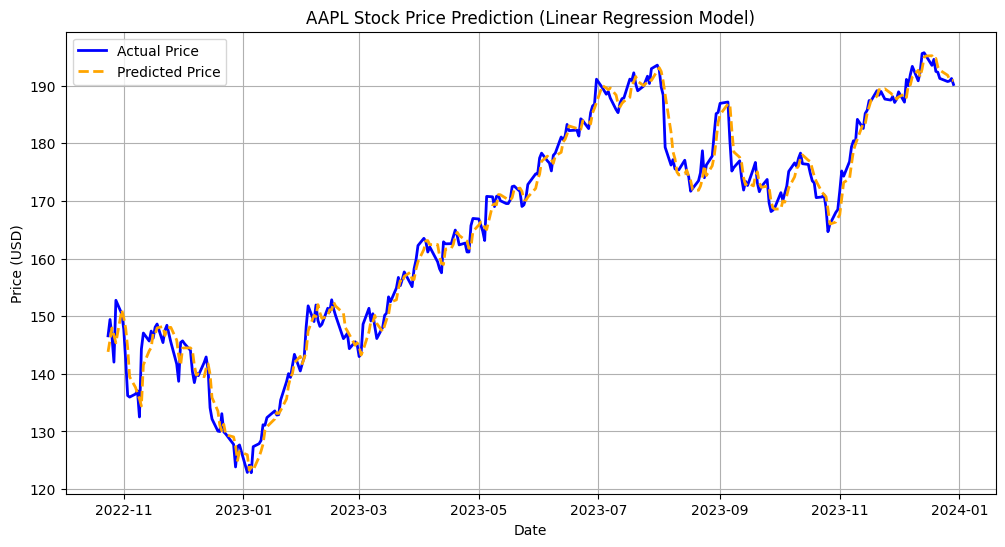

In [1]:
# 1. Install required library for fetching real stock data
!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2. Fetch historical stock data (Default: Apple Inc. - AAPL)
ticker = 'AAPL'
print(f"Downloading historical data for {ticker}...")
df = yf.download(ticker, start='2018-01-01', end='2024-01-01')

# 3. Feature Engineering: Create predictors based on past days
# Predicting target 'Close' price using previous day close and moving averages
df['Prev_Close'] = df['Close'].shift(1)
df['5MA'] = df['Close'].rolling(window=5).mean()
df['20MA'] = df['Close'].rolling(window=20).mean()

# Drop missing values caused by rolling windows
df = df.dropna()

# 4. Define Features (X) and Target (y)
X = df[['Prev_Close', '5MA', '20MA']]
y = df['Close']

# 5. Split dataset into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 6. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Make Predictions
y_pred = model.predict(X_test)

# 8. Evaluate Model Performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")

# 9. Plot Actual vs Predicted Stock Prices
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual Price', color='blue', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predicted Price', color='orange', linestyle='--', linewidth=2)
plt.title(f'{ticker} Stock Price Prediction (Linear Regression Model)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()